In [1]:
import importlib.util

import numpy as np
import torch
from pathlib import Path
from Bio.PDB import PDBParser
from tqdm.auto import tqdm

MODEL = "14_18052026"

_spec = importlib.util.spec_from_file_location('pocket_model', f'./models/{MODEL}.py')
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

PocketFinder                = _mod.PocketFinder
AA_TO_IDX                   = _mod.AA_TO_IDX
PHYSCHEM                    = _mod.PHYSCHEM
compute_structural_features = _mod.compute_structural_features
compute_hse                 = _mod.compute_hse

In [2]:
CHECKPOINT = f'./models/{MODEL}.pt'

state    = torch.load(CHECKPOINT, map_location='cpu')
in_dim   = state['embedding.weight'].shape[1]
hidden   = state['embedding.weight'].shape[0]
n_layers = sum(1 for k in state if k.startswith('convs.') and k.endswith('.eps'))

model = PocketFinder(in_dim=in_dim, hidden=hidden, n_layers=n_layers)
model.load_state_dict(state)
model.eval()
print(f'loaded: in_dim={in_dim}  hidden={hidden}  n_layers={n_layers}  '
      f'params={sum(p.numel() for p in model.parameters())}')

loaded: in_dim=18  hidden=256  n_layers=4  params=541505


In [3]:
DATASET_DIR = Path('./data/p2rank-datasets')
MLIG_DS     = DATASET_DIR / 'coach420(mlig).ds'

_pdb_parser = PDBParser(QUIET=True)


def parse_mlig_ds(path):
    entries = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#') or line.startswith('HEADER'):
                continue
            parts = line.split()
            entries[DATASET_DIR / parts[0]] = set(parts[1].split(',')) if len(parts) > 1 else set()
    return entries


def target_chain(pdb_path):
    # filename convention: 1a26A.pdb → chain A, 148lE.pdb → chain E
    return pdb_path.stem[-1]


def parse_pdb_protein(path):
    chain_id  = target_chain(path)
    structure = _pdb_parser.get_structure('p', str(path))
    coords, residue_names = [], []
    for residue in structure.get_residues():
        if residue.get_id()[0] != ' ':
            continue
        if residue.get_parent().get_id() != chain_id:
            continue
        res_name = residue.get_resname()
        if res_name not in AA_TO_IDX or 'CA' not in residue:
            continue
        coords.append(residue['CA'].get_vector().get_array())
        residue_names.append(res_name)

    coords     = np.array(coords, dtype=np.float32)
    physchem   = np.array([PHYSCHEM[r] for r in residue_names], dtype=np.float32)
    structural = compute_structural_features(coords)
    hse        = compute_hse(coords)

    def norm(x):
        std = x.std(axis=0)
        std[std < 1e-8] = 1.0
        return (x - x.mean(axis=0)) / std

    h = np.concatenate([norm(physchem), norm(structural), norm(hse)], axis=1)

    return torch.tensor(coords, dtype=torch.float32), torch.tensor(h, dtype=torch.float32)


def extract_ligand_coords(path, ligand_codes):
    structure = _pdb_parser.get_structure('p', str(path))
    coords = [
        atom.get_vector().get_array()
        for residue in structure.get_residues()
        if residue.get_resname() in ligand_codes
        for atom in residue.get_atoms()
    ]
    return torch.tensor(np.array(coords), dtype=torch.float32) if coords else None


entries = parse_mlig_ds(MLIG_DS)
print(f'{len(entries)} proteins in coach420(mlig)')

300 proteins in coach420(mlig)


In [4]:
# CA-to-ligand-atom distance threshold for defining pocket residues.
# scPDB uses protein atoms within 6.5 Å of the ligand; using 6.5 Å here
# from CA approximates the same pocket definition.
LABEL_DIST     = 6.5
PROB_THRESHOLD = 0.6
BETA           = 2.0

total_tp = total_fp = total_fn = 0
per_f1          = []
per_f2          = []
all_probs       = []
all_labels      = []
all_min_dists   = []
pocket_pos_list = []
entry_list      = []
errors          = []

with torch.no_grad():
    for pdb_path, ligand_codes in tqdm(entries.items()):
        try:
            pos, h    = parse_pdb_protein(pdb_path)
            ligand_pos = extract_ligand_coords(pdb_path, ligand_codes)
        except Exception as e:
            errors.append((pdb_path.name, str(e)))
            continue

        if len(pos) == 0 or ligand_pos is None or len(ligand_pos) == 0:
            continue

        min_dists = torch.cdist(pos, ligand_pos).min(dim=1).values
        labels    = (min_dists < LABEL_DIST).float()
        batch     = torch.zeros(len(pos), dtype=torch.long)
        probs     = model(h, pos, batch).sigmoid()
        preds     = (probs > PROB_THRESHOLD).float()

        all_probs.append(probs)
        all_labels.append(labels)
        all_min_dists.append(min_dists)
        pocket_pos_list.append(pos[preds == 1].numpy())
        entry_list.append(pdb_path)

        tp = (preds * labels).sum().item()
        fp = (preds * (1 - labels)).sum().item()
        fn = ((1 - preds) * labels).sum().item()
        total_tp += tp; total_fp += fp; total_fn += fn

        p = tp / (tp + fp + 1e-8)
        r = tp / (tp + fn + 1e-8)
        per_f1.append(2 * p * r / (p + r + 1e-8))
        per_f2.append((1 + BETA**2) * p * r / (BETA**2 * p + r + 1e-8))

all_probs     = torch.cat(all_probs).numpy()
all_labels    = torch.cat(all_labels).numpy()
all_min_dists = torch.cat(all_min_dists).numpy()
print(f'done — {len(per_f1)} proteins evaluated  ({len(errors)} errors)')

  0%|          | 0/300 [00:00<?, ?it/s]

done — 299 proteins evaluated  (0 errors)


In [5]:
micro_p  = total_tp / (total_tp + total_fp + 1e-8)
micro_r  = total_tp / (total_tp + total_fn + 1e-8)
micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r + 1e-8)
micro_f2 = (1 + BETA**2) * micro_p * micro_r / (BETA**2 * micro_p + micro_r + 1e-8)

print(f'proteins evaluated : {len(per_f1)}')
print()
print(f'micro precision : {micro_p:.3f}')
print(f'micro recall    : {micro_r:.3f}')
print(f'micro F1        : {micro_f1:.3f}')
print(f'micro F{BETA:.0f}        : {micro_f2:.3f}')
print()
print(f'macro F1 (mean)   : {sum(per_f1)/len(per_f1):.3f}')
print(f'macro F1 (median) : {sorted(per_f1)[len(per_f1)//2]:.3f}')
print(f'macro F{BETA:.0f} (mean)   : {sum(per_f2)/len(per_f2):.3f}')
print(f'macro F{BETA:.0f} (median) : {sorted(per_f2)[len(per_f2)//2]:.3f}')
print()
print(f'total TP={int(total_tp)}  FP={int(total_fp)}  FN={int(total_fn)}')

proteins evaluated : 299

micro precision : 0.369
micro recall    : 0.589
micro F1        : 0.454
micro F2        : 0.526

macro F1 (mean)   : 0.435
macro F1 (median) : 0.478
macro F2 (mean)   : 0.547
macro F2 (median) : 0.628

total TP=4282  FP=7326  FN=2988


In [6]:
from sklearn.cluster import DBSCAN

CLUSTER_EPS    = 8.0
CLUSTER_MINPTS = 3
DCA_THRESHOLDS = [4, 6, 8]

hits  = {t: 0 for t in DCA_THRESHOLDS}
total = 0

for pdb_path, pocket_pos, ligand_codes in zip(entry_list, pocket_pos_list, [entries[p] for p in entry_list]):
    ligand_pos = extract_ligand_coords(pdb_path, ligand_codes)
    if ligand_pos is None or len(pocket_pos) == 0:
        continue
    ligand_pos = ligand_pos.numpy()

    if len(pocket_pos) < CLUSTER_MINPTS:
        centroids = [pocket_pos.mean(axis=0)]
    else:
        cl = DBSCAN(eps=CLUSTER_EPS, min_samples=CLUSTER_MINPTS).fit_predict(pocket_pos)
        cluster_ids = [i for i in set(cl) if i >= 0]
        if not cluster_ids:
            continue
        centroids = [pocket_pos[cl == i].mean(axis=0) for i in cluster_ids]

    centroid_arr = np.stack(centroids)
    dists = np.linalg.norm(centroid_arr[:, None] - ligand_pos[None], axis=-1)
    min_dist_per_cluster = dists.min(axis=1)

    total += 1
    for t in DCA_THRESHOLDS:
        if (min_dist_per_cluster < t).any():
            hits[t] += 1

print(f'proteins evaluated : {total}\n')
for t in DCA_THRESHOLDS:
    print(f'  DCA < {t} Å  :  {100*hits[t]/total:.1f}%  ({hits[t]}/{total})')

proteins evaluated : 296

  DCA < 4 Å  :  65.9%  (195/296)
  DCA < 6 Å  :  80.7%  (239/296)
  DCA < 8 Å  :  88.2%  (261/296)


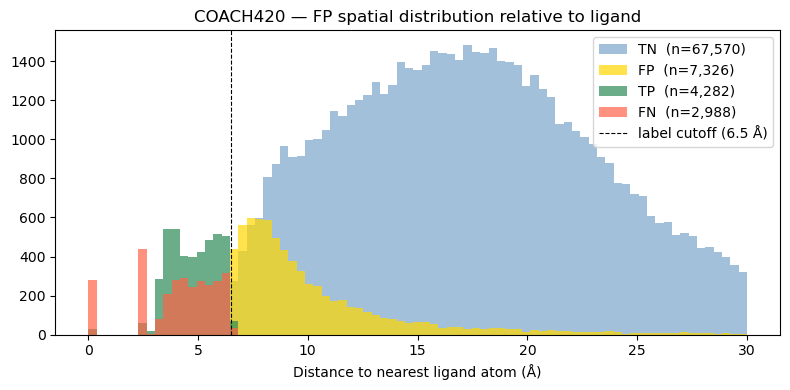

FP residues within X Å of the ligand:
  <  4 Å : 0.0%
  <  6 Å : 0.0%
  <  8 Å : 30.3%
  < 10 Å : 61.5%
  < 12 Å : 75.9%


In [7]:
import matplotlib.pyplot as plt

preds    = all_probs > PROB_THRESHOLD
fp_dists = all_min_dists[(preds == 1) & (all_labels == 0)]
tp_dists = all_min_dists[(preds == 1) & (all_labels == 1)]
tn_dists = all_min_dists[(preds == 0) & (all_labels == 0)]
fn_dists = all_min_dists[(preds == 0) & (all_labels == 1)]

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 30, 80)
for dists, label, color, alpha in [
    (tn_dists, 'TN', 'steelblue', 0.5),
    (fp_dists, 'FP', 'gold',    0.7),
    (tp_dists, 'TP', 'seagreen',  0.7),
    (fn_dists, 'FN', 'tomato',       0.7),
]:
    ax.hist(dists, bins=bins, density=False, alpha=alpha, color=color,
            label=f'{label}  (n={len(dists):,})')
ax.axvline(LABEL_DIST, color='k', linestyle='--', lw=0.8,
           label=f'label cutoff ({LABEL_DIST} Å)')
ax.set_xlabel('Distance to nearest ligand atom (Å)')
# ax.set_ylabel('Density')
ax.set_title('COACH420 — FP spatial distribution relative to ligand')
ax.legend()
plt.tight_layout()
plt.show()

print('FP residues within X Å of the ligand:')
for d in [4, 6, 8, 10, 12]:
    print(f'  < {d:2d} Å : {100*(fp_dists < d).mean():.1f}%')